# IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

In [2]:
def Display(df):
    with pd.option_context('display.max_columns', None):
        display(df)

# IMPORT DATA BASE

In [3]:
path = rf"C:\Users\Pedro\OneDrive\03 _ FIAP\_ Fase 5\Projeto Datathon\Drive file"

base_22 = pd.read_excel(f'{path}\\BASE DE DADOS PEDE 2024 - DATATHON.xlsx', sheet_name='PEDE2022')
base_22.drop(['Idade 22'], axis=1, inplace=True)
base_22 = base_22.rename(columns={'Matem': 'Mat', 'Portug': 'Por', 'Inglês': 'Ing', 'Fase ideal': 'fase_ideal_aluno', 'Defas': 'Defasagem'})
base_22['ano_base'] = 2022


base_23 = pd.read_excel(f'{path}\\BASE DE DADOS PEDE 2024 - DATATHON.xlsx', sheet_name='PEDE2023')
colunas_vazias = ['INDE 23', 'Pedra 23', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'Destaque IPV.1', 'Idade']
base_23 = base_23.drop(colunas_vazias, axis=1).rename(columns={'INDE 2023': 'INDE 23', 'Pedra 2023': 'Pedra 23', 'Fase Ideal': 'fase_ideal_aluno'})
base_23['ano_base'] = 2023

base_24 = pd.read_excel(f'{path}\\BASE DE DADOS PEDE 2024 - DATATHON.xlsx', sheet_name='PEDE2024')
base_24.drop(['Idade'], axis=1, inplace=True)
base_24 = base_24.rename(columns={'Fase Ideal': 'fase_ideal_aluno'})
base_24['ano_base'] = 2024

In [4]:
base = pd.concat([base_22, base_23, base_24])

In [5]:
# base_23.isnull().sum()

base_24.columns

# base.columns

Index(['RA', 'Fase', 'INDE 2024', 'Pedra 2024', 'Turma', 'Nome Anonimizado',
       'Data de Nasc', 'Gênero', 'Ano ingresso', 'Instituição de ensino',
       'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'INDE 22', 'INDE 23',
       'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2',
       'Rec Av2', 'Avaliador3', 'Avaliador4', 'Avaliador5', 'Avaliador6',
       'IAA', 'IEG', 'IPS', 'IPP', 'Rec Psicologia', 'IDA', 'Mat', 'Por',
       'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'fase_ideal_aluno',
       'Defasagem', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'Escola',
       'Ativo/ Inativo', 'Ativo/ Inativo.1', 'ano_base'],
      dtype='object')

**RA:** Registro do aluno  <br>
**Fase:** Fase ...  <br>
**Turma:** Está relacionado ao *Nível de Aprendizado*  <br>
**Nome:** Nome do aluno  <br>
**Ano nasc:** Ano de nascimento do aluno  <br>
**Idade 22:** Idade referente ao ano de 2022  <br>
**Gênero:** Gênero do Aluno  <br>
**Ano ingresso:**  Ano em que ingressou na Passo Mágicos <br>
**Instituição de ensino:** Mostra instituiça o de Ensino do Aluno  <br>
**Pedra 20 | 21 | 22:**
<br>Classificaça o do Aluno baseado no numero do INDE, o conceito de classificaça o e dado por:  <br>

    - Quartzo – 2,405 a 5,506  <br>
    - A gata – 5,506 a 6,868  <br>
    - Ametista – 6,868 a 8,230  <br>
    - Topa zio – 8,230 a 9,294.  <br>
    - Cada Pedra possui uma descriça o.   <br>
**INDE 22:**  Indice do Desenvolvimento Educacional – Métrica de Processo Avaliativo Geral do Aluno; Dado pela Ponderação dos indicadores:

    - IAN, IDA, IEG, IAA, IPS, IPP e IPV<br>
**Cg:**  Classificação geral do aluno<br>
**Cf:**  Classificação do aluno na fase<br>
**Ct:**  Classificação do aluno na turma<br>
**Nº Av:**  Número do Avaliador<br>
**Avaliador1:**  Nome do primeiro valiador 1<br>
**Rec Av1:**  Recomendação do primeiro avaliador<br>
**Avaliador2:**  Nome do segundo Avaliador <br>
**Rec Av2:**  Recomendação do segundo avaliador<br>
**Avaliador3:**  Nome do terceiro Avaliador <br>
**Rec Av3:**  Recomendação do terceiro avaliador<br>
**Avaliador4:**  Nome do quarto Avaliador <br>
**Rec Av4:**  Recomendação do quarto avaliador<br>
**IAA:**  Indicador de auto avaliação<br>
**IEG:**  Indicador de engajamento<br>
**IPS:**  Indicador psicossocial<br>
**Rec Psicologia:**  Recomendação da equipe psicológica<br>
**IDA:**  Indicador de aprendeizagem<br>
**Matem:**  Média das notas de Matemática<br>
**Portug:**  Média das notas de português<br>
**Inglês:**  Média das notas de inglês<br>
**Indicado:**  Indicador por alguma bolsa no período<br>
**Atingiu PV:**  Indica se o aluno atingiu o "Ponto de virada" - booleano<br>
**IPV:**  Indicador de ponto virada<br>
**IAN:**  Indicador de adequação ao nível - adequação ao nível atual<br>
**Fase ideal:**  Nivel ideal do aluno na Passos Magícos<br>
**Defas:**  Mostra o nivel de defasagem do aluno<br>
**Destaque IEG:**  Observação dos avaliadores sobre o aluno referente ao IEG - indicador de engajamento<br>
**Destaque IDA:**  Observação dos avaliadores sobre o aluno referente ao IDA - indicador de aprendizagem<br>
**Destaque IPV:**  Observação dos avaliadores sobre o aluno referente ao  IPV - indicador de ponto virada

# Renomear campos

In [6]:
base = base.rename(
    columns={
        'RA': 'registro_aluno',
        'Fase': 'fase_aluno',
        'Turma': 'turma',
        'Nome': 'nome',
        'Ano nasc': 'ano_nasc',
        'Idade 22': 'idade',
        'Gênero': 'genero',
        'Ano ingresso': 'ano_inicio_pm',
        'Instituição de ensino': 'instituicao_aluno',
        'Pedra 20': 'classificacao_aluno_2020',
        'Pedra 21': 'classificacao_aluno_2021',
        'Pedra 22': 'classificacao_aluno_2022',
        # 'INDE 22': 'indice_desenvolvimento_eduacional',
        'Cg': 'CG', 
        'Cf': 'CF',
        'Ct': 'CT',
        # 'Nº Av': 'numero_avaliador',
        'Avaliador1': 'nome_primeiro_avaliador',
        'Rec Av1': 'recomendacao_1',
        'Avaliador2': 'nome_avaliador2',
        'Rec Av2': 'recomendacao_2',
        'Avaliador3': 'nome_avaliador3', 
        'Rec Av3': 'recomendacao_3',
        'Avaliador4': 'nome_avaliador4',
        'Rec Av4': 'recomendacao_4',
        # 'IAA': 'indicador_auto_avaliacao',
        # 'IEG': 'indicador_engajamento',
        # 'IPS': 'indicador_psicossocial', 
        'Rec Psicologia': 'recomendacao_psicologica',
        # 'IDA': 'indicador_aprendizagem',
        # 'Matem': 'media_nota_matematica',
        # 'Portug': 'media_nota_português',
        'Inglês': 'Ingles',
        'Indicado': 'indicado_por_bolsa',
        # 'Atingiu PV': 'atingiu_ponde_virada',
        # 'IPV': 'indicaor_ponto_virada',
        # 'IAN': 'indicador_adequacao',
        # 'Fase ideal': 'fase_ideal_aluno',
        'Defasagem': 'defasagem_aluno',
        'Destaque IEG': 'observacao_engajamento',
        'Destaque IDA': 'observacao_aprendizagem',
        'Destaque IPV': 'observacao_ponto_virada'
    }
)

# Dimenssões da base

In [7]:
base.shape

(3030, 54)

# Valores nulos

In [8]:
base.isnull().sum()

registro_aluno                 0
fase_aluno                     0
turma                          0
nome                        2170
ano_nasc                    2170
genero                         0
ano_inicio_pm                  0
instituicao_aluno              1
classificacao_aluno_2020    2276
classificacao_aluno_2021    1969
classificacao_aluno_2022    1098
INDE 22                     1098
CG                          2170
CF                          2170
CT                          2170
Nº Av                         76
nome_primeiro_avaliador      203
recomendacao_1              2170
nome_avaliador2              203
recomendacao_2              2170
nome_avaliador3              996
recomendacao_3              2170
nome_avaliador4             1979
recomendacao_4              2734
IAA                          165
IEG                           76
IPS                          171
recomendacao_psicologica    2170
IDA                          178
Mat                          184
Por       

# colunas

In [9]:
base.columns

Index(['registro_aluno', 'fase_aluno', 'turma', 'nome', 'ano_nasc', 'genero',
       'ano_inicio_pm', 'instituicao_aluno', 'classificacao_aluno_2020',
       'classificacao_aluno_2021', 'classificacao_aluno_2022', 'INDE 22', 'CG',
       'CF', 'CT', 'Nº Av', 'nome_primeiro_avaliador', 'recomendacao_1',
       'nome_avaliador2', 'recomendacao_2', 'nome_avaliador3',
       'recomendacao_3', 'nome_avaliador4', 'recomendacao_4', 'IAA', 'IEG',
       'IPS', 'recomendacao_psicologica', 'IDA', 'Mat', 'Por', 'Ing',
       'indicado_por_bolsa', 'Atingiu PV', 'IPV', 'IAN', 'fase_ideal_aluno',
       'defasagem_aluno', 'observacao_engajamento', 'observacao_aprendizagem',
       'observacao_ponto_virada', 'ano_base', 'INDE 23', 'Pedra 23',
       'Nome Anonimizado', 'Data de Nasc', 'IPP', 'INDE 2024', 'Pedra 2024',
       'Avaliador5', 'Avaliador6', 'Escola', 'Ativo/ Inativo',
       'Ativo/ Inativo.1'],
      dtype='object')

# Transformando dados

## Tipo de dados

In [10]:
base['IAA'] = base['IAA'].astype(float)
base['IEG'] = base['IEG'].astype(float)
base['IPS'] = base['IPS'].astype(float)
base['IDA'] = base['IDA'].astype(float)
base['IPV'] = base['IPV'].astype(float)
base['IPP'] = base['IPP'].astype(float)
base['Mat'] = base['Mat'].astype(float)
base['Por'] = base['Por'].astype(float)
base['Ing'] = base['Ing'].astype(float)
base['IPV'] = base['IPV'].astype(float)
base['IAN'] = base['IAN'].astype(float)
base['INDE 22'] = base['INDE 22'].astype(float)
base['INDE 23'] = base['INDE 23'].astype(float)
base["INDE 24"] = pd.to_numeric(base["INDE 2024"], errors="coerce")
base.drop('INDE 2024', axis=1, inplace=True)
base['CG'] = base['CG'].astype(float)
base['CF'] = base['CF'].astype(float)
base['CT'] = base['CT'].astype(float)

base['Data de Nasc'] = pd.to_datetime(base['Data de Nasc'], errors='coerce')

base['idade'] = base['ano_base'] - base['Data de Nasc'].dt.year

base['fase_num'] = base['fase_aluno'].str.extract('(\d+)').astype(float)

### Substituir valores

In [11]:
# -------------------------
# padronizar
# -------------------------

base['Pedra 2024'] = base['Pedra 2024'].replace('INCLUIR', np.nan)

base['genero'] = base['genero'].replace({
    'Menina':'Feminino',
    'Menino':'Masculino'
})

base['fase_aluno'] = base['fase_aluno'].astype(str).str.upper()

base['fase_aluno'] = base['fase_aluno'].str.replace('FASE ','')

## Drop de colunas

In [12]:
# -------------------------
# remover colunas inúteis
# -------------------------

cols_drop = [
    'Ativo/ Inativo',
    'Ativo/ Inativo.1',
    'Avaliador6'
]

base = base.drop(columns=cols_drop, errors='ignore')

## Padronizar os dados

In [13]:
base['pedra'] = base['Pedra 2024']
base['pedra'] = base['pedra'].fillna(base['Pedra 23'])

## Agregar 3 anos em uma única coluna

In [14]:
base["INDE"] = np.where(
    base["ano_base"] == 2022, base["INDE 22"],
    np.where(
        base["ano_base"] == 2023, base["INDE 23"],
        base["INDE 24"]
    )
)

## Mitigar erros

In [15]:
# reset total
base = base.copy().reset_index(drop=True)

# remover colunas duplicadas
base = base.loc[:, ~base.columns.duplicated()]

# garantir índice único
base = base.reset_index(drop=True)

# garantir tipos
base['INDE'] = pd.to_numeric(base['INDE'], errors='coerce')

# ANALISE EXPLORATÓRIA

## HISTOGRAMA

<Axes: xlabel='INDE', ylabel='Count'>

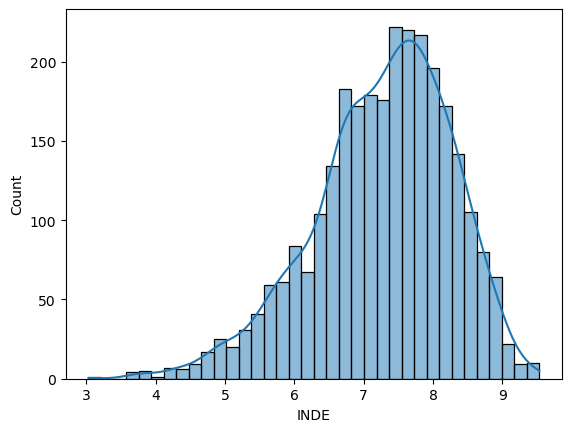

In [16]:

sns.histplot(base['INDE'], kde=True)


#### Analise do grafico acima:

- Nivel médio dos alunos que se mantem tem alta concentração entre 7,5 e 8.
- A maioria dos alunos estão com alto desempenho, tendo sua maioria para INDE acima de 6

## DESEMPENHO DO ALUNO

In [17]:
base['INDE'] = pd.to_numeric(base['INDE'], errors='coerce')
base['fase_num'] = pd.to_numeric(base['fase_num'], errors='coerce')

base['fase_cat'] = base['fase_aluno'].astype(str)

base['fase_cat'] = base['fase_cat'].replace({
    'ALFA': '0 - ALFA'
})

# ordenar corretamente
ordem = ['0 - ALFA','1','2','3','4','5','6','7','8','9']

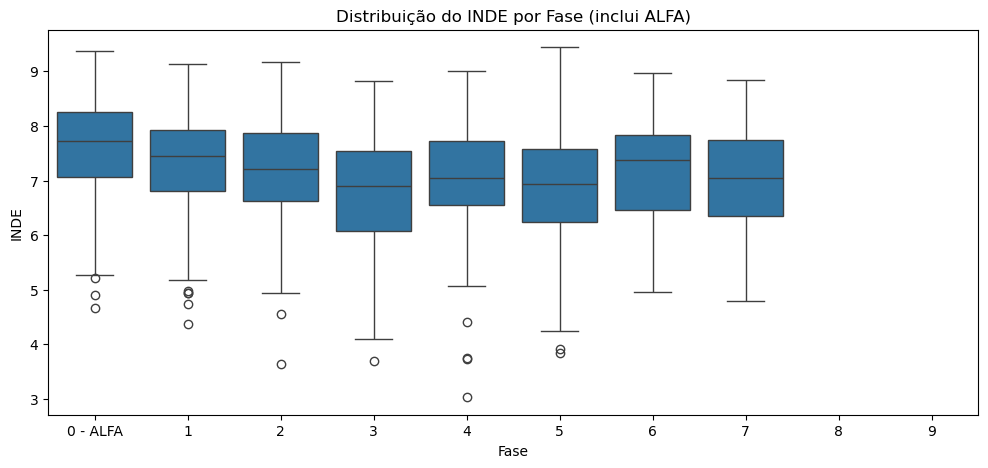

In [18]:
# remover nulos só do gráfico
df_plot = base[['fase_cat','INDE']].dropna()

plt.figure(figsize=(12,5))
sns.boxplot(data=df_plot, x='fase_cat', y='INDE', order=ordem)
plt.title('Distribuição do INDE por Fase (inclui ALFA)')
plt.xlabel('Fase')
plt.ylabel('INDE')
plt.show()

In [19]:
display(base[base.fase_num.isnull()].fase_aluno.unique())

array(['7', '6', '5', '4', '3', '2', '1', '0', 'ALFA', '9'], dtype=object)

#### Analise da tabela acima:

- Fase 1 → ~7.6

- Fase 2 → ~7.4

- Fase 3 → ~7.1 (queda)

- Fase 4–6 → recuperação gradual

- Fase 7 → melhor desempenho (~8.1)

- Fase 8 e 9 - Fase do Aluno = ALFA

## DESEMPENHO POR MATERIA

In [20]:
base[['INDE','Mat','Por','Ing']].corr()

,INDE,Mat,Por,Ing
INDE,1.000000,0.655727,0.641840,0.671397
Mat,0.655727,1.000000,0.479060,0.451294
Por,0.641840,0.479060,1.000000,0.470235
Ing,0.671397,0.451294,0.470235,1.000000


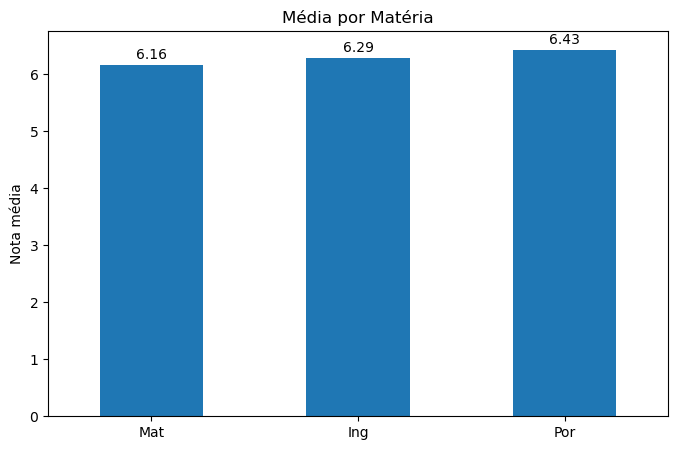

In [21]:
materias = base[['Mat', 'Por', 'Ing']].mean().sort_values()

plt.figure(figsize=(8,5))
ax = materias.plot(kind='bar')

# adicionar rótulos
for i, v in enumerate(materias.values):
    ax.text(i, v + 0.1, f'{v:.2f}', ha='center')

plt.title('Média por Matéria')
plt.ylabel('Nota média')
plt.xticks(rotation=0)
plt.show()

#### Analise da tabela acima:

- As 3 matérias tem grande influência no INDE - apresentando mais de 60% de correlação
    - Tendo o Inglês com a maior correlação

## DEFASAGEM ESCOLAR

In [22]:
base.groupby('defasagem_aluno', as_index=False).INDE.mean()

,defasagem_aluno,INDE
0,-5,5.031000
1,-4,4.841508
2,-3,6.037668
3,-2,6.723788
4,-1,7.051578
5,0,7.706885
6,1,7.996013
7,2,7.716205
8,3,7.213644


Destaques:
- Pior grupo: defasagem -4 e -5
- Melhor grupo: defasagem +1
    - Alunos na idade correta (0) já apresentam bom desempenho (~7.7)

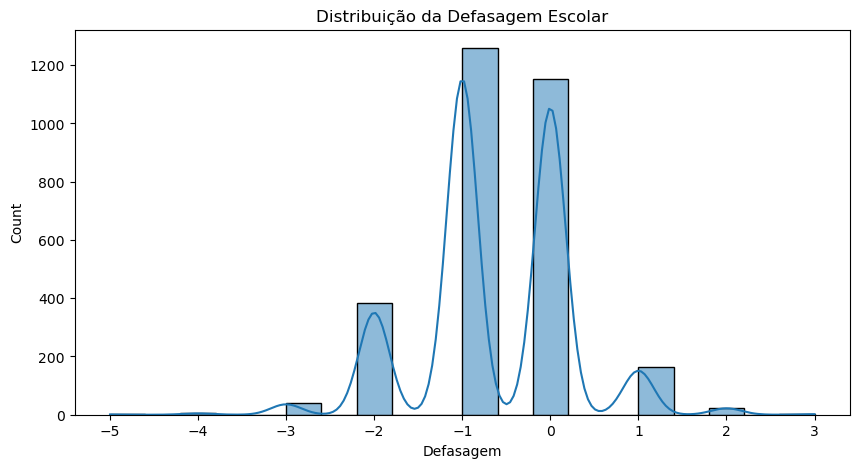

In [23]:
plt.figure(figsize=(10,5))
sns.histplot(base['defasagem_aluno'], bins=20, kde=True)
plt.title('Distribuição da Defasagem Escolar')
plt.xlabel('Defasagem')
plt.show()

In [24]:
defasagem_cat = pd.cut(
    base['defasagem_aluno'],
    bins=[-10, -1, 0, 10],
    labels=['Adiantado', 'Ideal', 'Atrasado']
)

print(defasagem_cat.value_counts(normalize=True)*100)

defasagem_aluno
Adiantado    55.676568
Ideal        38.019802
Atrasado      6.303630
Name: proportion, dtype: float64


### INDICES PEDAGÓGICOS

In [25]:
base[['INDE','IAN','IEG','IPP','IPV','IDA','IPS','IAA']].corr()

,INDE,IAN,IEG,IPP,IPV,IDA,IPS,IAA
INDE,1.000000,0.405309,0.745330,0.540295,0.720896,0.785311,0.199618,0.397226
IAN,0.405309,1.000000,-0.060345,0.123398,0.148880,0.118487,0.004548,0.034162
IEG,0.745330,-0.060345,1.000000,0.328542,0.558200,0.539057,-0.046264,0.133078
IPP,0.540295,0.123398,0.328542,1.000000,0.606649,0.369218,0.064209,0.054461
IPV,0.720896,0.148880,0.558200,0.606649,1.000000,0.557072,-0.048750,0.062728
IDA,0.785311,0.118487,0.539057,0.369218,0.557072,1.000000,0.022485,0.115241
IPS,0.199618,0.004548,-0.046264,0.064209,-0.048750,0.022485,1.000000,0.157373
IAA,0.397226,0.034162,0.133078,0.054461,0.062728,0.115241,0.157373,1.000000


indicadores pedagógicos mais determinantes:
- IDA (0.78)
- IEG (0.75)
- IPV (0.72)
<br>
- IPS (0.19) quase não impacta o INDE

O desempenho acadêmico (INDE) apresenta forte correlação com os indicadores IDA, IEG e IPV, sugerindo que estes fatores são os principais determinantes do progresso educacional dos alunos no programa.

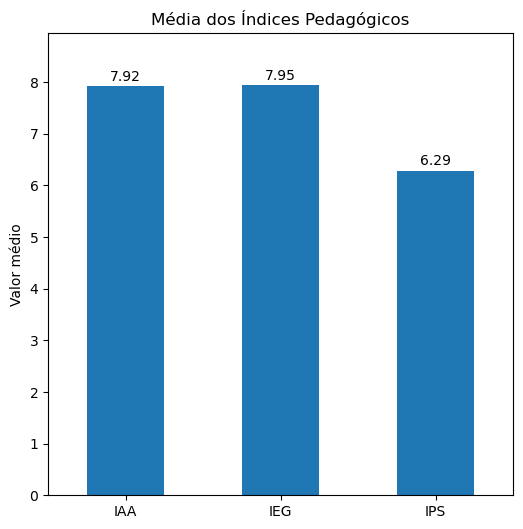

In [26]:
indices = base[['IAA', 'IEG', 'IPS']].mean()

plt.figure(figsize=(6,6))
ax = indices.plot(kind='bar')

# rótulos
for i, v in enumerate(indices.values):
    ax.text(i, v + 0.1, f'{v:.2f}', ha='center')

plt.title('Média dos Índices Pedagógicos')
plt.ylabel('Valor médio')
plt.xticks(rotation=0)

# ajuste de limite (evita cortar texto)
plt.ylim(0, indices.max() + 1)

plt.show()

- IAA ≈ 7.92 → bom desempenho acadêmico
- IEG ≈ 7.95 → bom engajamento
- IPS ≈ 6.29 → ponto fraco (psicológico)

O problema não é desempenho nem engajamento — é emocional/psicológico

### COMPARAÇÃO ENTRE ESCOLAS

In [27]:
base_escola = base[~base['Escola'].str.contains('Universi|Faculdade|FGV|INSPER|Unicamp|ESPM', na=False)]

base_escola.groupby('Escola')['INDE'].mean().sort_values()

Escola
Colégio Albert Einstein - SP                 6.182235
EM Eurides José Amorim                       6.211460
EE Alexandre Rodrigues Nogueira              6.736270
EE João Ortiz Rodrigues                      6.791759
João Friaza Colégio                          6.848313
EE Mario Francisco de Amorim                 6.851273
EE Donizetti Aparecido Leite Professor       6.948484
EE Francisco de Paula Teixeira               6.976266
EE Loris Nassif Mattar Profa                 7.014985
EE Leonice de Aquino Oliveira                7.019246
EM Cecilia Cristina de Oliveira Rodrigues    7.059971
EE Maria André Schunck Dona                  7.157855
EE Olivia de Faria Nogueira                  7.205066
EE Paschoal Carlos Magno                     7.205387
EM Etelvina Delfim Simões                    7.206983
Colégio Nogueira e Sonho de Criança          7.264754
Concluiu o 3º EM                             7.269364
EE Luiz Schunck                              7.431562
EE Joaquim Mendes Fel

Escolas com menor desempenho (Possível foco de intervenção pedagógica)
- Colégio Albert Einstein - SP → 6.18
- EM Eurides José Amorim → 6.21
- EE Alexandre Rodrigues Nogueira → 6.73
- EE João Ortiz Rodrigues → 6.79
- João Friaza Colégio → 6.85

Escolas com maior desempenho (Possíveis casos de boas práticas pedagógicas)
- EE Neide Celestina de Oliveira Profa → 8.53
- Colégio Arco Íris Evolução → 8.39
- EE Jardim Campestre → 8.32
- Escola João Paulo II → 8.16
- EE Jardim Silvania → 8.13

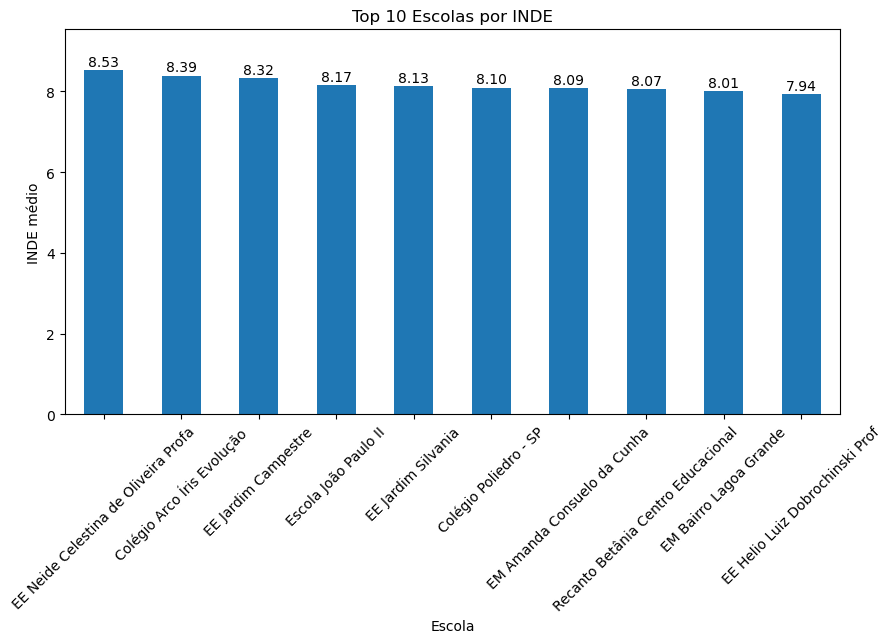

In [28]:
top_escolas = (
    base.groupby('Escola')['INDE']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
ax = top_escolas.plot(kind='bar')

# rótulos
for i, v in enumerate(top_escolas.values):
    ax.text(i, v + 0.1, f'{v:.2f}', ha='center')

plt.title('Top 10 Escolas por INDE')
plt.ylabel('INDE médio')
plt.xticks(rotation=45)

# evita cortar
plt.ylim(0, top_escolas.max() + 1)

plt.show()

## BOLSA vs DESEMPENHO

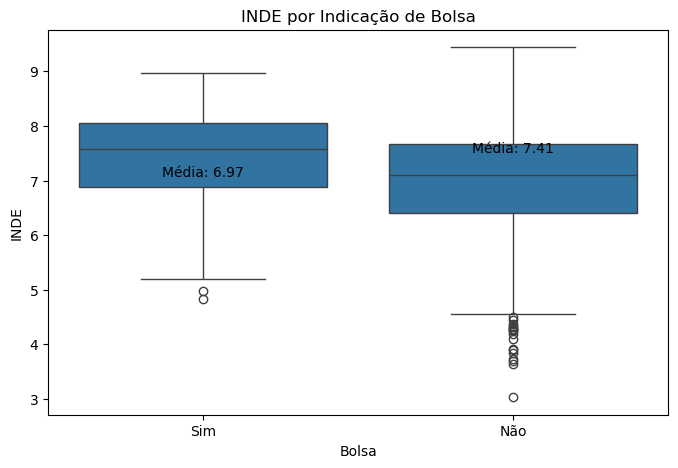

In [29]:
plt.figure(figsize=(8,5))
ax = sns.boxplot(data=base, x='indicado_por_bolsa', y='INDE')

# calcular média por grupo
medias = base.groupby('indicado_por_bolsa')['INDE'].mean()

# adicionar rótulos
for i, v in enumerate(medias.values):
    ax.text(i, v + 0.1, f'Média: {v:.2f}', ha='center', color='black')

plt.title('INDE por Indicação de Bolsa')
plt.xlabel('Bolsa')
plt.ylabel('INDE')
plt.show()

- Bolsa não está sendo dada para os melhores alunos
- Provável critério:
    - social (não performance)
    - ou erro de direcionamento

Alunos não bolsistas apresentam desempenho superior, indicando que o critério de concessão de bolsas não está diretamente relacionado à performance.

## CORRELAÇÃO

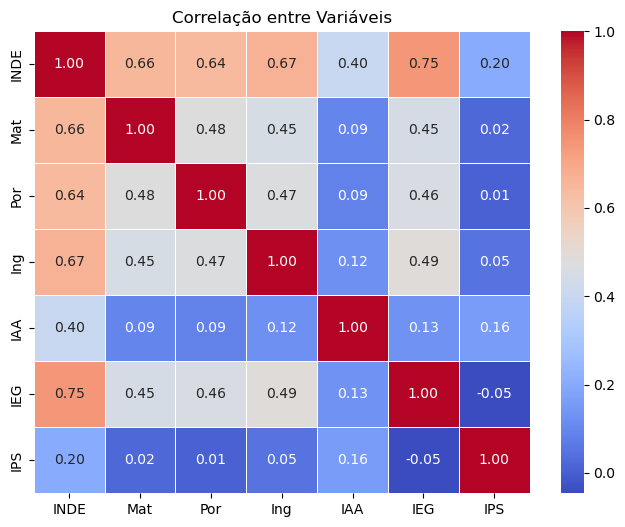

In [30]:
corr = base[['INDE','Mat','Por','Ing','IAA','IEG','IPS']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlação entre Variáveis')
plt.show()

- IEG (0.75) → 🔥 principal fator
- Ing (0.67)
- Mat (0.66)
- Por (0.64)
- IAA (0.40)
- IPS (0.20) → quase irrelevante

O principal fator de desempenho dos alunos é o engajamento, superando inclusive as notas acadêmicas tradicionais

- Bolsistas têm menor INDE
- INDE depende de engajamento

Talvez bolsistas tenham menor engajamento

## TESTE DE BOLSISTAS

In [31]:
from scipy.stats import ttest_ind

bolsa_sim = base[base['indicado_por_bolsa'] == 'Sim']['INDE'].dropna()
bolsa_nao = base[base['indicado_por_bolsa'] == 'Não']['INDE'].dropna()

stat, p = ttest_ind(bolsa_sim, bolsa_nao, equal_var=False)

print(f'p-value: {p:.5f}', "\n\nDiferença é estatisticamente significativa")

p-value: 0.00000 

Diferença é estatisticamente significativa


In [32]:
base.groupby(['fase_cat','indicado_por_bolsa'])['INDE'].mean().unstack()

indicado_por_bolsa,Não,Sim
fase_cat,,
0,7.316426,7.983143
1,7.086988,8.028957
2,6.902905,7.988375
3,6.424667,7.261097
4,6.982960,7.048192
5,6.840298,7.001769
6,7.164500,7.329500
7,6.216875,6.892385


- Bolsistas têm desempenho MAIOR que não bolsistas

- Possível:
    - Bolsistas concentrados em fases mais difíceis
    - Não bolsistas em fases mais fáceis
      
Puxando a média geral para baixo. Apesar da média geral indicar menor desempenho, ao analisar por fase, alunos bolsistas apresentam desempenho superior de forma consistente.

<Figure size 1200x500 with 0 Axes>

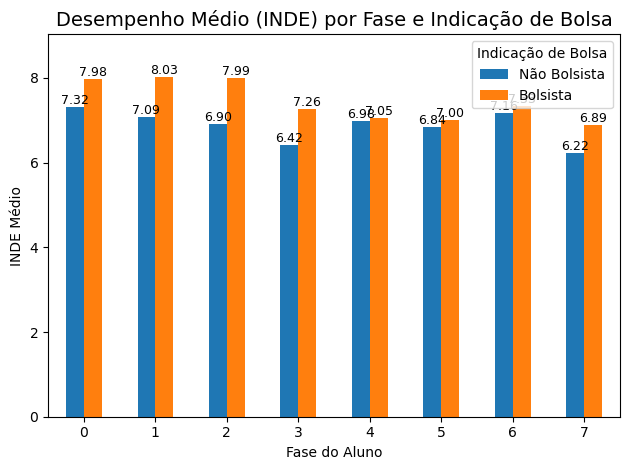

In [33]:
plot_df = (
    base.groupby(['fase_cat','indicado_por_bolsa'])['INDE']
    .mean()
    .unstack()
)

plt.figure(figsize=(12,5))
ax = plot_df.plot(kind='bar')

# títulos
plt.title('Desempenho Médio (INDE) por Fase e Indicação de Bolsa', fontsize=14)
plt.xlabel('Fase do Aluno')
plt.ylabel('INDE Médio')

# legenda mais clara
plt.legend(title='Indicação de Bolsa', labels=['Não Bolsista', 'Bolsista'])

# eixo X organizado
plt.xticks(rotation=0)

# rótulos nas barras
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

# ajuste de limite
plt.ylim(0, plot_df.max().max() + 1)

plt.tight_layout()
plt.show()

# Responder as perguntas do projeto

In [34]:
df_analise = base.copy()

## Adequação do nível (IAN)

-  Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?

In [35]:
df_analise['categoria_defasagem'] = pd.cut(
    df_analise['IAN'],
    bins=[0,5,7,10],
    labels=[
        'Severamente defasado',
        'Moderadamente defasado',
        'Adequado'
    ]
)

df_analise['categoria_defasagem'].value_counts()

categoria_defasagem
Severamente defasado      1687
Adequado                  1343
Moderadamente defasado       0
Name: count, dtype: int64

In [36]:
pd.crosstab(
    df_analise['ano_base'],
    df_analise['categoria_defasagem']
)

categoria_defasagem,Severamente defasado,Adequado
ano_base,,
2022,601,259
2023,552,462
2024,534,622


In [37]:
df_analise.groupby('ano_base')['IAN'].mean()

ano_base
2022    6.424419
2023    7.243590
2024    7.683824
Name: IAN, dtype: float64

## Desempenho acadêmico (IDA)

- O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

##### Média por ano

In [38]:
df_analise.groupby('ano_base')['IDA'].mean()

ano_base
2022    6.092907
2023    6.663394
2024    6.351422
Name: IDA, dtype: float64

##### Média por fase

- Agrupando a fase de acordo com o Número e não as possíveis "Salas"

In [39]:
temp = df_analise.groupby('fase_num', as_index=False)['IDA'].mean()
temp[temp.IDA.notnull()].sort_values('IDA')

,fase_num,IDA
2,3.0,5.501312
3,4.0,5.935327
6,7.0,6.235816
4,5.0,6.237172
1,2.0,6.502214
0,1.0,6.802095
5,6.0,6.990517
7,8.0,8.000000


##### Evolução Ano x Fase

- fase num - Referência ao número da fase - desconsiderando as possíveis "Salas"

In [40]:
pd.pivot_table(
    df_analise,
    values='IDA',
    index='fase_num',
    columns='ano_base',
    aggfunc='mean'
)

ano_base,2023,2024
fase_num,,
1.0,6.814451,6.790541
2.0,6.736683,6.250000
3.0,5.746970,5.347630
4.0,6.004255,5.878986
5.0,5.904615,6.453333
6.0,6.809091,7.230000
7.0,7.810000,5.810360
8.0,NaN,8.000000


## Engajamento nas atividades (IEG)

- O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

##### Correlação

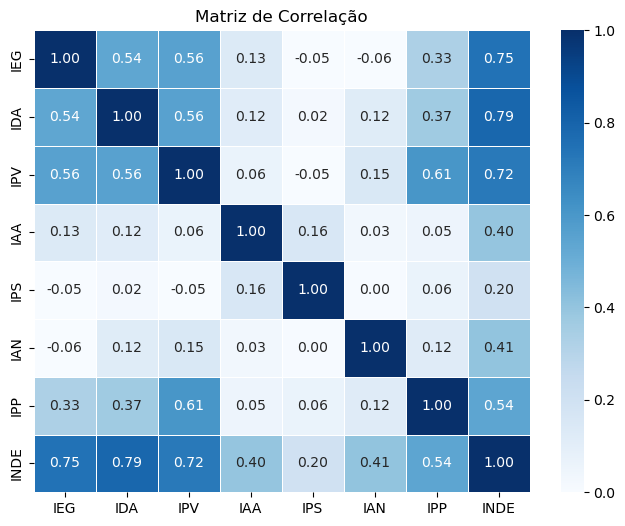

In [41]:
corr = df_analise[['IEG','IDA','IPV','IAA','IPS','IAN','IPP', 'INDE']].corr()

# criar heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='Blues',   # cor única
    vmin=0,         # força mínima
    vmax=1,         # força máxima
    fmt='.2f',
    linewidths=0.5
)

plt.title('Matriz de Correlação')
plt.show()

- Analise:
    - O grau de engajamento tem moderada relação com os indices de IDA e de IPV
    - O INDE gera o maior grau de confiança na correlação dos dados
        - Quanto maior o INDE, os alunos tendem a ter um melhor engajamento

## Autoavaliação (IAA)

- As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

In [42]:
df_analise[['IAA','IDA','IEG']].corr()

,IAA,IDA,IEG
IAA,1.000000,0.115241,0.133078
IDA,0.115241,1.000000,0.539057
IEG,0.133078,0.539057,1.000000


## Aspectos psicossociais (IPS)

- Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

- IPS	| <t> indicador psicossocial que queremos avaliar
- IDA	| <t> mede desempenho acadêmico
- IEG	| <t> mede engajamento do aluno

In [43]:
df_analise[['IPS','IDA','IEG']].corr()

,IPS,IDA,IEG
IPS,1.000000,0.022485,-0.046264
IDA,0.022485,1.000000,0.539057
IEG,-0.046264,0.539057,1.000000


In [44]:
df_analise.groupby(pd.qcut(df_analise['IPS'],4))[['IDA','IEG']].mean()

,IDA,IEG
IPS,,
"(2.499, 5.02]",6.258992,8.321242
"(5.02, 7.5]",6.205639,8.042163
"(7.5, 7.51]",6.530051,8.234814
"(7.51, 10.0]",6.806833,8.536252


- Quanto maior o IPS, maior o desempenho acadêmico.
- Alunos com melhores condições psicossociais têm maior engajamento.

In [45]:
df_analise['queda_IDA'] = df_analise['IDA'].diff()

df_analise[['IPS','queda_IDA']].corr()

,IPS,queda_IDA
IPS,1.000000,0.041769
queda_IDA,0.041769,1.000000


- Correlação praticamente nula
- IPS não explica diretamente quedas de desempenho acadêmico

## Aspectos psicopedagógicos (IPP)

- As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

In [46]:
df_analise[['IPP','IAN']].corr()

,IPP,IAN
IPP,1.000000,0.123398
IAN,0.123398,1.000000


##### Comparação média de IPP por nível de defasagem

In [47]:
df_analise.groupby('categoria_defasagem')['IPP'].mean()

categoria_defasagem
Severamente defasado      7.452178
Moderadamente defasado         NaN
Adequado                  7.678196
Name: IPP, dtype: float64

##### Distribuição

In [48]:
pd.crosstab(
    df_analise['categoria_defasagem'],
    pd.qcut(df_analise['IPP'],4)
)

IPP,"(2.499, 7.083]","(7.083, 7.5]","(7.5, 8.125]","(8.125, 10.0]"
categoria_defasagem,,,,
Severamente defasado,319,288,268,209
Adequado,180,226,261,241


- Alunos severamente defasados concentram-se mais em IPP baixos.
- Alunos adequados aparecem mais em IPP altos.

## Ponto de virada (IPV)

- Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

##### Correlação com IPV

In [49]:
df_analise[['IPV','IDA','IEG','IAA','IPS','IAN']].corr()['IPV'].sort_values(ascending=False)

IPV    1.000000
IEG    0.558200
IDA    0.557072
IAN    0.148880
IAA    0.062728
IPS   -0.048750
Name: IPV, dtype: float64

##### Influência das notas acadêmicas

In [50]:
df_analise[['IPV','Mat','Por','Ing']].corr()['IPV'].sort_values(ascending=False)

IPV    1.000000
Ing    0.495606
Por    0.477207
Mat    0.455459
Name: IPV, dtype: float64

- Alunos mais engajados e com melhor desempenho têm maior probabilidade de atingir ponto de virada.
- Melhor desempenho nas disciplinas está associado a maior IPV.
- Fatores de adequação, autoavaliação e psicossociais têm pouca influência direta no IPV.

## Multidimensionalidade dos indicadores

- Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

##### Correlação com INDE

In [51]:
df_analise[['INDE','IDA','IEG','IPS','IPP']].corr()['INDE'].sort_values(ascending=False)

INDE    1.000000
IDA     0.785311
IEG     0.745330
IPP     0.540295
IPS     0.199618
Name: INDE, dtype: float64

##### Análise combinada

In [52]:
df_analise.groupby(
[
pd.qcut(df_analise['IDA'],3),
pd.qcut(df_analise['IEG'],3),
pd.qcut(df_analise['IPS'],3),
pd.qcut(df_analise['IPP'],3)
]
)['INDE'].mean().sort_values(ascending=False).head(10)

IDA          IEG             IPS             IPP           
(7.4, 10.0]  (9.132, 10.0]   (7.51, 10.0]    (7.969, 10.0]     8.691729
                             (6.255, 7.51]   (7.969, 10.0]     8.605269
                             (7.51, 10.0]    (7.344, 7.969]    8.578445
             (7.821, 9.132]  (7.51, 10.0]    (7.969, 10.0]     8.306656
             (9.132, 10.0]   (6.255, 7.51]   (7.344, 7.969]    8.303563
             (7.821, 9.132]  (6.255, 7.51]   (7.969, 10.0]     8.286918
             (9.132, 10.0]   (7.51, 10.0]    (2.499, 7.344]    8.270190
(5.7, 7.4]   (9.132, 10.0]   (6.255, 7.51]   (7.969, 10.0]     8.188491
(7.4, 10.0]  (9.132, 10.0]   (2.499, 6.255]  (7.969, 10.0]     8.178632
             (7.821, 9.132]  (7.51, 10.0]    (7.344, 7.969]    8.170635
Name: INDE, dtype: float64

- IDA alto + IEG muito alto + IPS alto + IPP alto
<br><t>→ INDE ≈ 8.69 (maior valor)

- IDA alto + IEG muito alto + IPS médio + IPP alto
<br><t>INDE ≈ 8.60

- IDA alto + IEG alto + IPS alto + IPP médio/alto
<br><t> INDE ≈ 8.57

- O fator mais consistente nas maiores notas de INDE é:
- IEG muito alto (engajamento) junto com IDA alto (desempenho acadêmico).
- IPS e IPP reforçam o resultado, mas têm impacto menor que IDA e IEG.

## Previsão de risco com Machine Learning

- Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.

## Efetividade do programa

- Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

In [53]:
df_analise.groupby('fase_aluno')[['INDE','IDA','IEG','IAN']].mean().sort_values('INDE').head(50)

,INDE,IDA,IEG,IAN
fase_aluno,,,,
3F,6.091569,4.105556,5.275916,7.916667
1H,6.499682,5.791667,7.006909,5.416667
3P,6.653246,4.288889,6.960647,8.000000
3M,6.720273,4.500000,7.357531,8.000000
4B,6.765209,5.137255,7.391818,6.764706
3,6.772533,5.427143,7.714643,7.267857
5,6.871127,5.889600,7.920800,6.500000
5D,6.877837,5.378788,7.442647,6.363636
3G,6.878809,4.844444,7.413974,8.333333


- INDE (nota global) - A maioria das fases está concentrada entre 7.0 e 7.4
    - Indica desempenho geral relativamente estável entre as fases.
- IDA (desempenho acadêmico) - Algumas fases iniciais apresentam IDA baixo (~4–5)
    - Há grande variação acadêmica entre turmas/fases.
- IEG (engajamento) - Na maioria das fases está acima de 7
    - O engajamento dos alunos é consistentemente alto.
- IAN (adequação de nível) - Muitos grupos estão entre 7 e 9
    - Indica presença relevante de defasagem educacional em várias fases.

In [54]:
df_analise.groupby('fase_num')[['INDE','IDA','IEG','IAN']].mean().sort_values('INDE')

,INDE,IDA,IEG,IAN
fase_num,,,,
3.0,7.052391,5.501312,7.794760,8.250729
4.0,7.199168,5.935327,8.129948,7.320574
5.0,7.235497,6.237172,8.465429,7.015152
2.0,7.371608,6.502214,8.398620,7.480519
6.0,7.501790,6.990517,8.627169,6.896552
1.0,7.510119,6.802095,8.611914,6.319832
7.0,7.632540,6.235816,7.809800,9.500000
8.0,NaN,8.000000,0.000000,10.000000


- INDE oscila entre 6.9 e 7.4, sem crescimento progressivo.
- IDA cai na fase 3, indicando possível momento crítico.
- IEG permanece alto (~8) em quase todas as fases.
- IAN aumenta na fase 7, indicando maior defasagem.